In [166]:
import matplotlib.pyplot as plt
import numpy as np
import pycosat as pc
import time

## Task 0

In [167]:
pc.__version__

'0.6.6'

## Task 1

### part A - encoding

In [168]:
(p, q, r) = int(1),int(2),int(3)
print(f'({p}, {q}, {r})')

(1, 2, 3)


In [169]:
clauses = [[p,q,-r], [-p,-q,r], [-p,-q,-r], [-p,q,-r], [-p,q,r] , [p,-q,-r]]

In [170]:
#isinstance(pc.solve(clauses), list)

In [171]:
N = 50
sign = np.random.default_rng().choice(np.array([-1,1]), size = N)
variables = np.random.default_rng().choice(a = np.arange(1,N+1), size = N, replace = False)*sign

In [172]:
variables

array([-43,  -5,  35,   2,   4, -12,  44, -20,   6, -16,  25, -50,  28,
       -29, -10,  14, -48,  26, -47, -27,  46, -49,  13, -37,  33, -32,
       -23, -24,   1, -39, -21,  38, -22, -45, -30,  15, -18,  42, -34,
        11,  -9,   8, -40,   3, -36, -17, -19,   7,  31, -41])

In [196]:
def create_logical_formula(N=50, M=5, k=3):
    rng = np.random.default_rng()
    clauses = []
    m = 0

    while m < M:
        indices = rng.choice(np.arange(1, N + 1), size=k, replace=False)
        signs = rng.choice([-1, 1], size=k)
        
        result = indices * signs
        clauses2int = [int(i) for i in result]
        clauses.append(clauses2int)
        m += 1
    
    return clauses

In [197]:
random_clauses = create_logical_formula() #default
random_clauses

[[26, 15, -43], [49, 48, -11], [-49, -29, -32], [12, 15, -39], [39, 31, 48]]

## Task 2

In [199]:
N = 20
f_range = np.arange(3, 7, 0.5) 
nsamp = 20

ratio = []
average_time = []

for f in f_range:
    m_val = int(f * N)
    results = []
    times = []
    for _ in range(nsamp):
        # Twoja funkcja - upewnij się, że przyjmuje M=m_val
        formula = create_logical_formula(N = N, M=m_val) 
        
        start = time.time()
        result = pc.solve(formula)
        stop = time.time()
        
        times.append(stop - start)
        
        # Kluczowa zmiana: w pycosat wynik SAT to lista, UNSAT to napis 'UNSAT'
        # Jeśli używasz innego solvera, upewnij się co zwraca
        results.append(result != 'UNSAT' and isinstance(result, list))

    sat_rate = sum(results) / nsamp
    av_time = sum(times) / nsamp
    ratio.append(sat_rate)
    average_time.append(av_time)
    
    print(f"Ratio {f}: SAT={sat_rate}, Time={av_time:.5f}")

Ratio 3.0: SAT=1.0, Time=0.00013
Ratio 3.5: SAT=1.0, Time=0.00005
Ratio 4.0: SAT=0.85, Time=0.00004
Ratio 4.5: SAT=0.55, Time=0.00006
Ratio 5.0: SAT=0.2, Time=0.00004
Ratio 5.5: SAT=0.2, Time=0.00006
Ratio 6.0: SAT=0.05, Time=0.00005
Ratio 6.5: SAT=0.0, Time=0.00005


In [207]:
N_new = 200
f_range = np.arange(3, 7, 0.1) 
nsamp = 20

ratio = []
average_time = []
for f in f_range:
    m_val = int(f * N_new)
    results = []
    times = []
    for _ in range(nsamp):
        formula = create_logical_formula(N = N_new, M=m_val)
        start = time.time()
        result = pc.solve(formula)
        stop = time.time()
        times.append(stop-start)
        results.append(result != 'UNSAT')

    
    sat_rate = sum(results) / nsamp
    av_time = sum(times) / nsamp
    ratio.append(sat_rate)
    average_time.append(av_time)

In [209]:
ratio 

[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.95,
 0.95,
 0.7,
 0.45,
 0.15,
 0.0,
 0.1,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

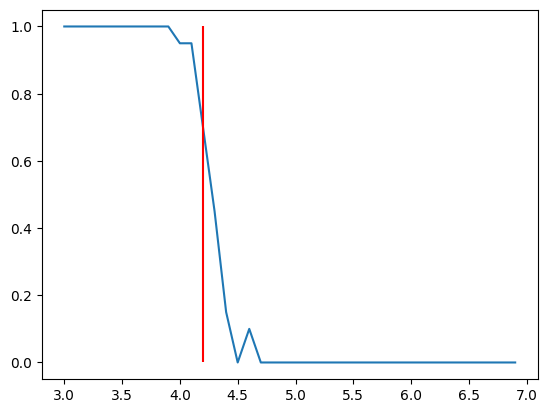

In [212]:
plt.plot(f_range, ratio)
plt.vlines(4.2, 0, 1, colors = 'red')

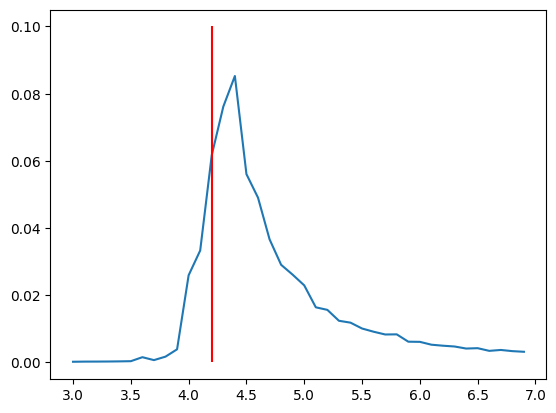

In [213]:
plt.plot(f_range, average_time)
plt.vlines(4.2, 0, 0.1, colors = 'red')